# Introdução à Regressão Linear

Neste notebook, vamos cobrir:
1. Básico de NumPy
2. Básico de Pandas
3. Gráficos com Matplotlib
4. Regressão Linear com **statsmodels** (OLS)
5. Regressão Linear com **scikit-learn**
6. Regressão Linear com a **fórmula OLS manual**

Todos os exemplos são construídos no contexto de **regressão supervisionada** — prever um target contínuo $y$ a partir de features $\mathbf{x}$.

---
## 1. Básico de NumPy

NumPy é a biblioteca fundamental para computação numérica em Python. Seu objeto principal é o **ndarray** (array n-dimensional), que permite operações vetorizadas rápidas sobre dados numéricos.

Em machine learning, representamos dados como matrizes e vetores — NumPy é como fazemos isso em Python.

In [1]:
import numpy as np

### 1.1 Criando arrays

Um array 1D é como um **vetor**, e um array 2D é como uma **matriz**.

In [2]:
# Um array 1D (vetor) — pense nele como uma coluna de feature,
# por exemplo, áreas de casas em metros quadrados
areas = np.array([50, 70, 80, 100, 120])
print("areas:", areas)
print("shape:", areas.shape)  # (5,) — 5 elementos, 1 dimensão

areas: [ 50  70  80 100 120]
shape: (5,)


In [3]:
# Um array 2D (matriz) — pense nele como um dataset com linhas=observações
# e colunas=features.
# Cada linha é uma casa: [área (m²), número de quartos]
X = np.array([
    [50,  2],
    [70,  3],
    [80,  3],
    [100, 4],
    [120, 5]
])
print("X (feature matrix):")
print(X)
print("shape:", X.shape)  # (5, 2) — 5 observações, 2 features

X (feature matrix):
[[ 50   2]
 [ 70   3]
 [ 80   3]
 [100   4]
 [120   5]]
shape: (5, 2)


### 1.2 Entendendo o `axis`

O parâmetro `axis` controla **em qual direção** uma operação é aplicada:

Para um array 2D com shape `(n, p)` (n linhas, p colunas):

| Parâmetro | Direção | Resultado | Dica |
|-----------|---------|-----------|------|
| `axis=0` | Ao longo das **linhas** (↓ para baixo) | Um valor **por coluna** | "Colapsa as linhas" |
| `axis=1` | Ao longo das **colunas** (→ para a direita) | Um valor **por linha** | "Colapsa as colunas" |

```
         col0  col1
row0  [  50,    2 ]
row1  [  70,    3 ]    axis=0: desce por cada coluna
row2  [  80,    3 ]    axis=1: vai para a direita em cada linha
row3  [ 100,    4 ]
row4  [ 120,    5 ]
```

In [4]:
# axis=0: calcula a média DESCENDO cada coluna → um resultado por feature
print("Média por coluna (axis=0):", X.mean(axis=0))
# → [média das áreas, média dos quartos] = [84.0, 3.4]

# axis=1: calcula a média ATRAVESSANDO cada linha → um resultado por observação
print("Média por linha  (axis=1):", X.mean(axis=1))
# → [média das features da casa 0, média das features da casa 1, ...]

Média por coluna (axis=0): [84.   3.4]
Média por linha  (axis=1): [26.  36.5 41.5 52.  62.5]


In [5]:
# Mais exemplos com axis
print("Soma por coluna (axis=0):", X.sum(axis=0))   # área total, quartos totais
print("Max por coluna  (axis=0):", X.max(axis=0))   # maior área, mais quartos
print("Min por linha   (axis=1):", X.min(axis=1))   # menor valor em cada linha

Soma por coluna (axis=0): [420  17]
Max por coluna  (axis=0): [120   5]
Min por linha   (axis=1): [2 3 3 4 5]


### 1.3 Operações vetorizadas e álgebra linear

NumPy realiza operações elemento a elemento **sem loops explícitos**, o que é mais rápido e mais legível. Isso importa muito em ML, onde constantemente fazemos multiplicações de matrizes.

In [6]:
# Operações elemento a elemento
prices = np.array([150000, 210000, 240000, 320000, 400000])
price_per_m2 = prices / areas
print("Preço por m²:", price_per_m2)

Preço por m²: [3000.         3000.         3000.         3200.         3333.33333333]


In [7]:
# Produto escalar — fundamental para regressão linear
# y_hat = theta^T x = theta_0*1 + theta_1*x_1 + theta_2*x_2
theta = np.array([10000, 2500, 5000])  # [coef intercept, coef área, coef quartos]
x_single = np.array([1, 80, 3])        # [termo de bias, área, quartos] para uma casa

y_hat = theta @ x_single  # produto escalar = 10000 + 2500*80 + 5000*3
print(f"Preço previsto: {y_hat}")  # isto é exatamente y_hat = theta^T x

Preço previsto: 225000


In [8]:
# Multiplicação de matrizes — prever para TODAS as casas de uma vez: y_hat = X @ theta
# Primeiro, adicionamos uma coluna de 1s (o termo de intercept/bias)
ones = np.ones((X.shape[0], 1))
X_with_intercept = np.hstack([ones, X])  # agora shape é (5, 3)
print("Design matrix X (com coluna de intercept):")
print(X_with_intercept)

y_hat_all = X_with_intercept @ theta
print("\nPreços previstos:", y_hat_all)

Design matrix X (com coluna de intercept):
[[  1.  50.   2.]
 [  1.  70.   3.]
 [  1.  80.   3.]
 [  1. 100.   4.]
 [  1. 120.   5.]]

Preços previstos: [145000. 200000. 225000. 280000. 335000.]


### 1.4 Funções úteis para criação de arrays

In [9]:
print("zeros:", np.zeros(3))
print("ones:", np.ones(4))
print("range:", np.arange(0, 10, 2))       # início, fim, passo
print("linspace:", np.linspace(0, 1, 5))   # 5 pontos igualmente espaçados de 0 a 1

# Dados aleatórios (úteis para simulações)
np.random.seed(42)
print("random normal:", np.random.randn(5))  # 5 amostras de N(0,1)

zeros: [0. 0. 0.]
ones: [1. 1. 1. 1.]
range: [0 2 4 6 8]
linspace: [0.   0.25 0.5  0.75 1.  ]
random normal: [ 0.49671415 -0.1382643   0.64768854  1.52302986 -0.23415337]


---
## 2. Básico de Pandas

Pandas é construído sobre o NumPy e fornece estruturas de dados **rotuladas**. Os dois objetos principais são:
- **Series**: um array 1D rotulado (como uma coluna)
- **DataFrame**: uma tabela 2D rotulada (como uma planilha ou tabela SQL)

Em ML, tipicamente carregamos nosso dataset em um DataFrame, exploramos os dados, e depois convertemos as partes relevantes para arrays NumPy para modelagem.

In [10]:
import pandas as pd

### 2.1 Criando um DataFrame

In [11]:
# Criar um DataFrame — nosso dataset de "preços de casas"
df = pd.DataFrame({
    'area_m2':    [50, 70, 80, 100, 120, 60, 90, 110, 75, 95],
    'rooms':      [2,  3,  3,  4,   5,   2,  3,  4,   3,  4],
    'age_years':  [30, 20, 15, 5,   2,   25, 10, 8,   18, 12],
    'price_1000': [150, 210, 240, 320, 400, 170, 280, 350, 220, 290]
})
df

,area_m2,rooms,age_years,price_1000
0,50,2,30,150
1,70,3,20,210
2,80,3,15,240
3,100,4,5,320
4,120,5,2,400
5,60,2,25,170
6,90,3,10,280
7,110,4,8,350
8,75,3,18,220
9,95,4,12,290


In [12]:
# Exploração rápida
print("Shape:", df.shape)   # (10 observações, 4 colunas)
print("Colunas:", list(df.columns))
print("Tipos de dados:")
print(df.dtypes)

Shape: (10, 4)
Colunas: ['area_m2', 'rooms', 'age_years', 'price_1000']
Tipos de dados:
area_m2       int64
rooms         int64
age_years     int64
price_1000    int64
dtype: object


In [13]:
# Estatísticas descritivas — uma visão rápida da distribuição de cada feature
df.describe()

,area_m2,rooms,age_years,price_1000
count,10.000000,10.000000,10.000000,10.000000
mean,85.000000,3.300000,14.500000,263.000000
std,22.110832,0.948683,8.872554,79.728707
min,50.000000,2.000000,2.000000,150.000000
25%,71.250000,3.000000,8.500000,212.500000
50%,85.000000,3.000000,13.500000,260.000000
75%,98.750000,4.000000,19.500000,312.500000
max,120.000000,5.000000,30.000000,400.000000


### 2.2 Selecionando dados

In [14]:
# Selecionar uma única coluna → retorna uma Series
print(df['area_m2'])
print("\nTipo:", type(df['area_m2']))

0     50
1     70
2     80
3    100
4    120
5     60
6     90
7    110
8     75
9     95
Name: area_m2, dtype: int64

Tipo: <class 'pandas.Series'>


In [15]:
# Selecionar múltiplas colunas → retorna um DataFrame
features = df[['area_m2', 'rooms', 'age_years']]
features.head()

,area_m2,rooms,age_years
0,50,2,30
1,70,3,20
2,80,3,15
3,100,4,5
4,120,5,2


In [16]:
# Filtrar linhas com uma condição
large_houses = df[df['area_m2'] > 90]
print("Casas maiores que 90 m²:")
large_houses

Casas maiores que 90 m²:


,area_m2,rooms,age_years,price_1000
3,100,4,5,320
4,120,5,2,400
7,110,4,8,350
9,95,4,12,290


### 2.3 `axis` no Pandas — mesma lógica do NumPy

O parâmetro `axis` funciona da mesma forma:
- `axis=0` → opera ao longo das **linhas** (para baixo), resultado tem um valor por **coluna**
- `axis=1` → opera ao longo das **colunas** (para a direita), resultado tem um valor por **linha**

In [17]:
# axis=0 (padrão): calcula a média de cada coluna
print("Média por coluna (axis=0):")
print(df.mean(axis=0, numeric_only=True))

Média por coluna (axis=0):
area_m2        85.0
rooms           3.3
age_years      14.5
price_1000    263.0
dtype: float64


In [ ]:
# axis=1: calcula a média entre as colunas para cada linha
# (nem sempre faz sentido, mas ilustra o conceito)
print("Média por linha (axis=1):")
print(df.mean(axis=1, numeric_only=True))

Média por linha (axis=1):
0     58.00
1     75.75
2     84.50
3    107.25
4    131.75
5     64.25
6     95.75
7    118.00
8     79.00
9    100.25
dtype: float64


In [19]:
# Um uso prático de axis=1: remover uma coluna
# axis=1 aqui significa "remover ao longo do eixo das colunas"
# (ou seja, remove uma coluna, não uma linha)
df_no_age = df.drop('age_years', axis=1)
df_no_age.head(3)

,area_m2,rooms,price_1000
0,50,2,150
1,70,3,210
2,80,3,240


### 2.4 De Pandas para NumPy

In [20]:
# Extrair o array NumPy subjacente — útil para alimentar dados em modelos
X_array = df[['area_m2', 'rooms', 'age_years']].values
y_array = df['price_1000'].values

print("X shape:", X_array.shape)  # (10, 3)
print("y shape:", y_array.shape)  # (10,)

X shape: (10, 3)
y shape: (10,)


---
## 3. Básico de Gráficos com Matplotlib

Visualização é essencial para entender os dados e os resultados do modelo. Usamos **matplotlib** para criar gráficos.

In [21]:
import matplotlib.pyplot as plt

%matplotlib inline

### 3.1 Gráfico de dispersão — visualizando a relação entre uma feature e o target

Essa é a primeira coisa que você deve fazer: **olhar para seus dados**. Em regressão, queremos ver se existe um padrão entre $x$ e $y$.

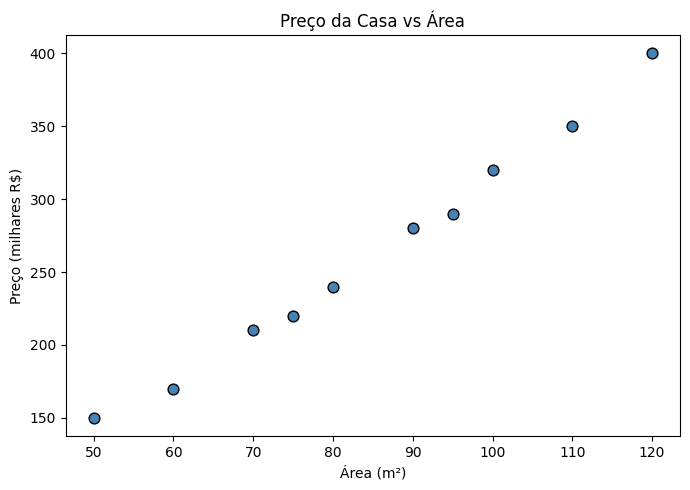

In [22]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(df['area_m2'], df['price_1000'], color='steelblue', s=60, edgecolors='black')
ax.set_xlabel('Área (m²)')
ax.set_ylabel('Preço (milhares R$)')
ax.set_title('Preço da Casa vs Área')
plt.tight_layout()
plt.show()

Há uma clara **tendência linear positiva**: conforme a área aumenta, o preço tende a aumentar. Isso sugere que um modelo linear $\hat{y} = \theta_0 + \theta_1 \cdot \text{area}$ pode ser um bom ajuste.

### 3.2 Múltiplos gráficos de dispersão — explorando todas as features

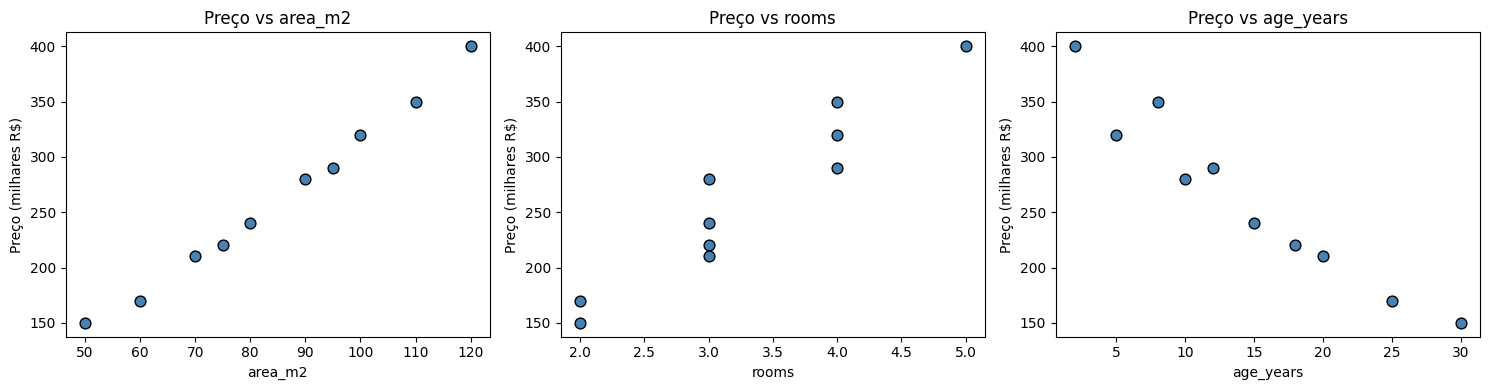

In [23]:
feature_cols = ['area_m2', 'rooms', 'age_years']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, feature_cols):
    ax.scatter(df[col], df['price_1000'], color='steelblue', s=60, edgecolors='black')
    ax.set_xlabel(col)
    ax.set_ylabel('Preço (milhares R$)')
    ax.set_title(f'Preço vs {col}')

plt.tight_layout()
plt.show()

Podemos observar:
- **area_m2**: relação positiva forte (casa maior → preço maior)
- **rooms**: relação positiva (mais quartos → preço maior)
- **age_years**: relação negativa (casa mais velha → preço menor)

Todas as três features parecem ter uma relação aproximadamente **linear** com o preço.

### 3.3 Desenhando uma reta sobre o gráfico de dispersão

Para visualizar um modelo de regressão, desenhamos a reta ajustada sobre os dados.

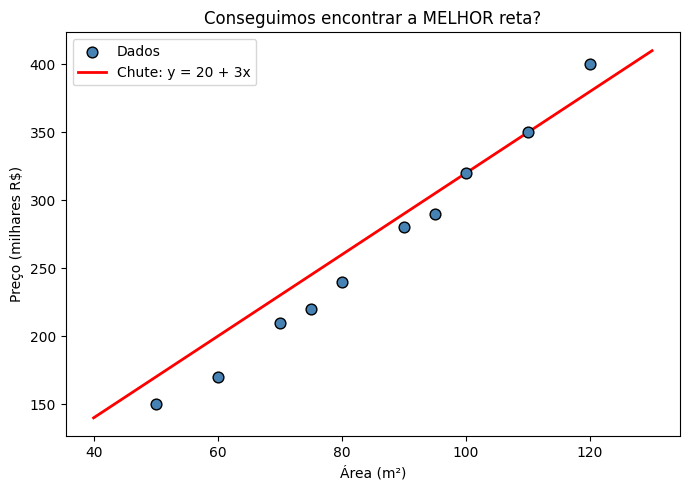

In [45]:
# Vamos desenhar manualmente uma reta "chute": preço ≈ 20 + 3.0 * área
x_line = np.linspace(40, 130, 100)
y_line = 20 + 3.0 * x_line

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(df['area_m2'], df['price_1000'], color='steelblue', s=60,
           edgecolors='black', label='Dados', zorder=5)
ax.plot(x_line, y_line, color='red', linewidth=2, label='Chute: y = 20 + 3x')
ax.set_xlabel('Área (m²)')
ax.set_ylabel('Preço (milhares R$)')
ax.set_title('Conseguimos encontrar a MELHOR reta?')
ax.legend()
plt.tight_layout()
plt.show()

O chute não é ruim, mas **como encontramos a reta ótima?** É isso que a regressão linear faz — ela encontra os parâmetros $\hat{\theta}$ que minimizam a soma dos erros quadráticos (SSE).

---

## 4. Regressão Linear — A Teoria

### O modelo

Modelamos o target como uma combinação linear das features:

$$\hat{y} = f(\mathbf{x}) = \theta^\top \mathbf{x} = \theta_0 + \theta_1 x_1 + \theta_2 x_2 + \cdots + \theta_p x_p$$

onde:
- $\theta_0$ é o **intercept** (termo de bias)
- $\theta_1, \ldots, \theta_p$ são os **coeficientes** (inclinações) para cada feature
- $p$ é o número de features

### A função de perda (L2 / erro quadrático)

Medimos quão ruim é uma previsão com o **erro quadrático**:

$$L(y, f(\mathbf{x})) = (y - f(\mathbf{x}))^2$$

### Risco empírico (SSE)

O erro total ao longo de todas as $n$ observações é a **soma dos erros quadráticos** (sum of squared errors):

$$\mathcal{R}_{\text{emp}}(\theta) = \sum_{i=1}^{n} \left(y^{(i)} - \theta^\top \mathbf{x}^{(i)}\right)^2 = \|\mathbf{y} - \mathbf{X}\theta\|_2^2$$

### A solução OLS

Igualando o gradiente a zero e resolvendo, obtemos o estimador **ordinary least squares** (método dos mínimos quadrados):

$$\hat{\theta} = (\mathbf{X}^\top \mathbf{X})^{-1} \mathbf{X}^\top \mathbf{y}$$

Esta é uma **solução analítica (forma fechada)** — não precisa de otimização iterativa!

---
## 5. Construindo um Dataset Adequado

Vamos criar um dataset maior e mais realista para nossos exemplos de regressão. Geraremos dados sintéticos onde a relação verdadeira é conhecida, para que possamos verificar nossos resultados.

**Cenário**: prever o **preço** (em milhares de reais) de uma casa baseado em:
- **area_m2**: área em metros quadrados
- **rooms**: número de quartos
- **age_years**: idade do imóvel em anos

Relação verdadeira (desconhecida pelo modelo):
$$\text{preço} = 50 + 2.5 \cdot \text{área} + 15 \cdot \text{quartos} - 1.5 \cdot \text{idade} + \epsilon$$

onde $\epsilon \sim \mathcal{N}(0, 20^2)$ é ruído aleatório.

In [46]:
np.random.seed(42)
n = 100  # número de casas

# Gerar features
area = np.random.uniform(40, 150, n)
rooms = np.random.randint(1, 7, n)
age = np.random.uniform(0, 50, n)

# Parâmetros verdadeiros
TRUE_INTERCEPT = 50
TRUE_BETA_AREA = 2.5
TRUE_BETA_ROOMS = 15
TRUE_BETA_AGE = -1.5

# Gerar target com ruído
noise = np.random.normal(0, 20, n)
price = (TRUE_INTERCEPT
         + TRUE_BETA_AREA * area
         + TRUE_BETA_ROOMS * rooms
         + TRUE_BETA_AGE * age
         + noise)

# Colocar em um DataFrame
houses = pd.DataFrame({
    'area_m2': area,
    'rooms': rooms,
    'age_years': age,
    'price_1000': price
})

houses.head(10)

,area_m2,rooms,age_years,price_1000
0,81.199413,1,25.409939,238.256414
1,144.578574,4,34.790640,404.696889
2,120.519334,5,42.917940,325.883664
3,105.852433,4,16.297945,359.538507
4,57.162050,6,11.012052,235.358369
5,57.159397,5,35.557477,204.352414
6,46.389197,5,40.475052,165.601392
7,135.279376,3,17.433299,410.955420
8,106.122651,5,4.808828,371.974489
9,117.887984,4,47.026163,331.626017


In [26]:
houses.describe()

,area_m2,rooms,age_years,price_1000
count,100.000000,100.000000,100.000000,100.000000
mean,91.719882,3.480000,27.561563,290.454902
std,32.723835,1.794942,13.892462,95.563402
min,40.607433,1.000000,0.903768,121.574505
25%,61.252084,2.000000,15.373492,206.981102
50%,91.055670,4.000000,26.479983,290.977444
75%,120.322343,5.000000,40.827666,370.798337
max,148.557563,6.000000,49.812685,476.290086


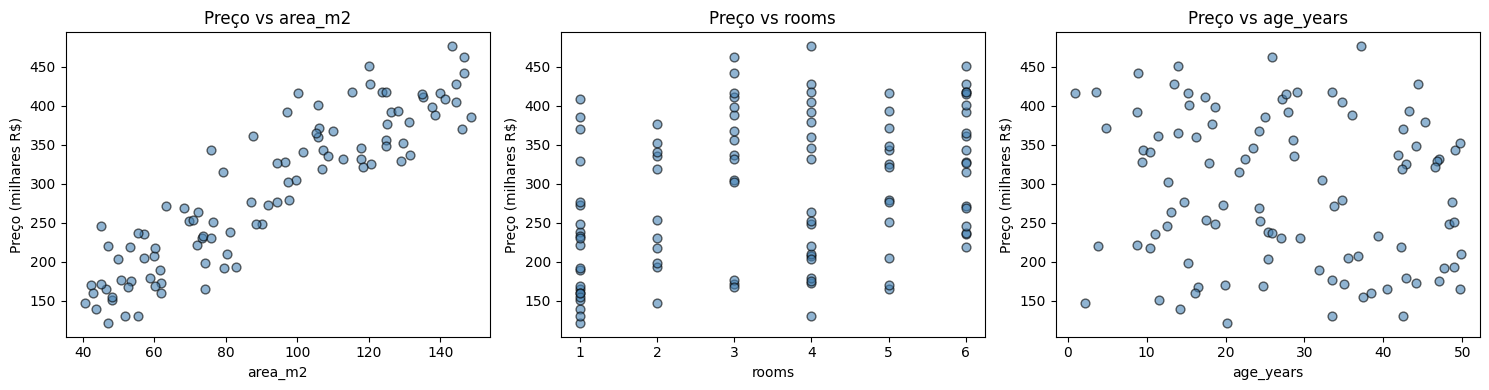

In [47]:
# Visualizar as relações feature-target
feature_names = ['area_m2', 'rooms', 'age_years']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, feature_names):
    ax.scatter(houses[col], houses['price_1000'], alpha=0.6,
               color='steelblue', edgecolors='black', s=40)
    ax.set_xlabel(col)
    ax.set_ylabel('Preço (milhares R$)')
    ax.set_title(f'Preço vs {col}')

plt.tight_layout()
plt.show()

---
## 6. Regressão Linear com `statsmodels` (OLS)

`statsmodels` é uma biblioteca Python focada em **modelagem estatística**. Sua implementação de OLS fornece um resumo rico incluindo:
- Estimativas dos coeficientes e seus erros padrão
- Estatísticas t e p-values (testes de significância)
- R-squared (qualidade do ajuste)
- Estatística F (significância geral do modelo)

Isso é o mais próximo do que você veria em um curso de estatística ou na função `lm()` do R.

In [48]:
import statsmodels.api as sm

In [49]:
# Preparar os dados
X_sm = houses[['area_m2', 'rooms', 'age_years']]
y_sm = houses['price_1000']

# IMPORTANTE: statsmodels NÃO adiciona o intercept por padrão.
# Precisamos adicionar manualmente com sm.add_constant().
X_sm = sm.add_constant(X_sm)  # adiciona uma coluna de 1s como primeira coluna
X_sm.head()

,const,area_m2,rooms,age_years
0,1.0,81.199413,1,25.409939
1,1.0,144.578574,4,34.790640
2,1.0,120.519334,5,42.917940
3,1.0,105.852433,4,16.297945
4,1.0,57.162050,6,11.012052


In [50]:
# Ajustar o modelo OLS
model_sm = sm.OLS(y_sm, X_sm).fit()

# Imprimir o resumo completo
print(model_sm.summary())

                            OLS Regression Results                            
Dep. Variable:             price_1000   R-squared:                       0.950
Model:                            OLS   Adj. R-squared:                  0.948
Method:                 Least Squares   F-statistic:                     604.4
Date:                Sun, 29 Mar 2026   Prob (F-statistic):           3.59e-62
Time:                        20:10:47   Log-Likelihood:                -447.87
No. Observations:                 100   AIC:                             903.7
Df Residuals:                      96   BIC:                             914.2
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         42.6796      8.422      5.067      0.0

### 6.1 Lendo o resumo (summary)

Vamos detalhar as partes principais do resumo:

#### Tabela de coeficientes

| Coluna | Significado |
|--------|-------------|
| **coef** | Valor estimado de $\hat{\theta}_j$. Ex: se `area_m2` tem coef ≈ 2.5, então aumentar a área em 1 m² aumenta o preço previsto em ~R$ 2.500 (*ceteris paribus* — mantendo o resto fixo) |
| **std err** | Erro padrão da estimativa — mede a incerteza no coeficiente |
| **t** | Estatística t = coef / std err. Testa $H_0: \theta_j = 0$ ("esta feature não tem efeito") |
| **P>|t|** | p-value. Se pequeno (< 0.05), rejeitamos $H_0$ e concluímos que a feature é **estatisticamente significativa** |
| **[0.025, 0.975]** | Intervalo de confiança de 95% para o coeficiente verdadeiro |

#### Estatísticas do modelo

| Métrica | Significado |
|---------|-------------|
| **R-squared** | $R^2 = 1 - \frac{\text{SSE}}{\text{SST}}$. Proporção da variância em $y$ explicada pelo modelo. Varia de 0 (modelo não explica nada) a 1 (ajuste perfeito). |
| **Adj. R-squared** | Ajustado pelo número de preditores — penaliza a adição de features inúteis |
| **F-statistic** | Testa se o modelo como um todo é significativo (pelo menos uma feature importa). F grande + p-value pequeno = modelo é útil. |
| **AIC / BIC** | Critérios de informação para comparação de modelos — menor é melhor |

In [31]:
# Extrair resultados específicos programaticamente
print("Coeficientes estimados:")
print(model_sm.params)
print(f"\nR²: {model_sm.rsquared:.4f}")
print(f"R² ajustado: {model_sm.rsquared_adj:.4f}")

Coeficientes estimados:
const        42.679561
area_m2       2.645905
rooms        14.065701
age_years    -1.591179
dtype: float64

R²: 0.9497
R² ajustado: 0.9481


In [32]:
# Comparar coeficientes estimados vs verdadeiros
true_params = [TRUE_INTERCEPT, TRUE_BETA_AREA, TRUE_BETA_ROOMS, TRUE_BETA_AGE]
param_names = ['const', 'area_m2', 'rooms', 'age_years']

comparison = pd.DataFrame({
    'Verdadeiro': true_params,
    'Estimado (statsmodels)': model_sm.params.values
}, index=param_names)

comparison

,Verdadeiro,Estimado (statsmodels)
const,50.0,42.679561
area_m2,2.5,2.645905
rooms,15.0,14.065701
age_years,-1.5,-1.591179


Os coeficientes estimados devem estar próximos dos valores verdadeiros, mas não exatos — o ruído ($\epsilon$) impede a recuperação perfeita.

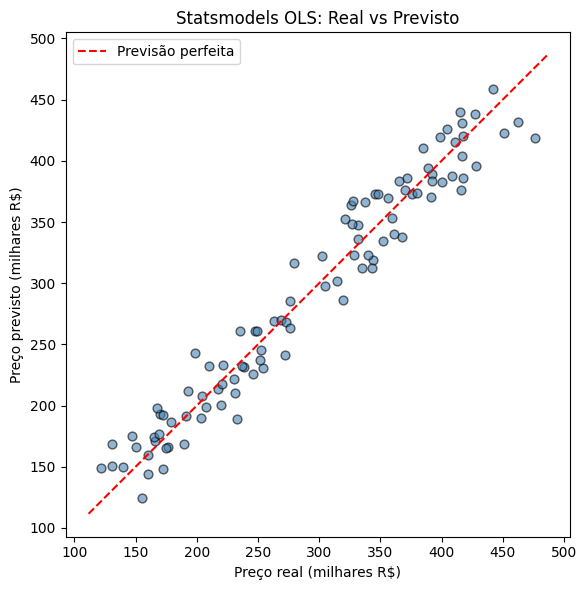

In [33]:
# Visualizar: valores reais vs previstos
y_pred_sm = model_sm.predict(X_sm)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_sm, y_pred_sm, alpha=0.6, color='steelblue', edgecolors='black', s=40)
# Linha de previsão perfeita
lims = [y_sm.min() - 10, y_sm.max() + 10]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Previsão perfeita')
ax.set_xlabel('Preço real (milhares R$)')
ax.set_ylabel('Preço previsto (milhares R$)')
ax.set_title('Statsmodels OLS: Real vs Previsto')
ax.legend()
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

---
## 7. Regressão Linear com `scikit-learn`

`scikit-learn` é a biblioteca de ML mais popular em Python. Sua API é projetada para **predição** e não para inferência estatística:
- Sem p-values ou intervalos de confiança
- Mas API mais simples, integra com pipelines, cross-validation, etc.

Vamos ajustar o mesmo modelo e comparar.

In [34]:
from sklearn.linear_model import LinearRegression

In [35]:
# scikit-learn adiciona o intercept automaticamente (não precisa de add_constant)
X_sk = houses[['area_m2', 'rooms', 'age_years']].values
y_sk = houses['price_1000'].values

# Ajustar o modelo
model_sk = LinearRegression()
model_sk.fit(X_sk, y_sk)

print("Intercept:", model_sk.intercept_)
print("Coeficientes:", model_sk.coef_)
print(f"R²: {model_sk.score(X_sk, y_sk):.4f}")

Intercept: 42.67956054763965
Coeficientes: [ 2.64590476 14.06570056 -1.59117855]
R²: 0.9497


### 7.1 Comparando statsmodels vs scikit-learn

Ambos usam a mesma fórmula OLS internamente, então os resultados devem ser **idênticos**.

In [36]:
comparison['Estimado (sklearn)'] = [
    model_sk.intercept_,
    *model_sk.coef_
]

comparison

,Verdadeiro,Estimado (statsmodels),Estimado (sklearn)
const,50.0,42.679561,42.679561
area_m2,2.5,2.645905,2.645905
rooms,15.0,14.065701,14.065701
age_years,-1.5,-1.591179,-1.591179


In [37]:
# As previsões também devem ser idênticas
y_pred_sk = model_sk.predict(X_sk)

max_diff = np.max(np.abs(y_pred_sm.values - y_pred_sk))
print(f"Diferença máxima entre previsões: {max_diff:.2e}")
print("Os resultados são numericamente idênticos (até a precisão de ponto flutuante).")

Diferença máxima entre previsões: 5.68e-13
Os resultados são numericamente idênticos (até a precisão de ponto flutuante).


### Diferenças principais entre as duas bibliotecas

| | statsmodels | scikit-learn |
|---|---|---|
| **Foco** | Inferência estatística | Predição |
| **Intercept** | Deve ser adicionado manualmente (`add_constant`) | Adicionado automaticamente |
| **Saída** | Resumo rico (p-values, IC, R², teste F) | Apenas coeficientes e R² |
| **Use quando** | Você precisa *explicar* quais features importam | Você precisa *prever* novos valores |

---
## 8. OLS Manual — Implementando a Fórmula na Mão

Agora vamos implementar o estimador OLS diretamente usando a fórmula:

$$\hat{\theta} = (\mathbf{X}^\top \mathbf{X})^{-1} \mathbf{X}^\top \mathbf{y}$$

Isso é o que tanto `statsmodels` quanto `scikit-learn` calculam internamente (com algumas otimizações numéricas).

### Derivação da fórmula (recapitulando os slides)

Queremos minimizar o risco empírico:

$$\mathcal{R}_{\text{emp}}(\theta) = \|\mathbf{y} - \mathbf{X}\theta\|_2^2$$

Passos:
1. Expandir: $\mathcal{R}_{\text{emp}}(\theta) = (\mathbf{y} - \mathbf{X}\theta)^\top(\mathbf{y} - \mathbf{X}\theta)$
2. Calcular o gradiente em relação a $\theta$ e igualar a zero (equações normais):
$$\frac{\partial \mathcal{R}_{\text{emp}}}{\partial \theta} = -2\mathbf{X}^\top(\mathbf{y} - \mathbf{X}\theta) = 0$$
3. Resolver para $\theta$:
$$\mathbf{X}^\top \mathbf{X} \theta = \mathbf{X}^\top \mathbf{y}$$
$$\hat{\theta} = (\mathbf{X}^\top \mathbf{X})^{-1} \mathbf{X}^\top \mathbf{y}$$

In [38]:
# Passo 1: Construir a design matrix X (adicionar coluna de 1s para o intercept)
X_manual = houses[['area_m2', 'rooms', 'age_years']].values
ones = np.ones((X_manual.shape[0], 1))
X_manual = np.hstack([ones, X_manual])  # shape: (100, 4)

y_manual = houses['price_1000'].values  # shape: (100,)

print("X shape:", X_manual.shape)
print("y shape:", y_manual.shape)
print("\nPrimeiras 5 linhas da design matrix:")
print(X_manual[:5])

X shape: (100, 4)
y shape: (100,)

Primeiras 5 linhas da design matrix:
[[  1.          81.19941307   1.          25.40993884]
 [  1.         144.57857371   4.          34.79064034]
 [  1.         120.5193336    5.          42.91794024]
 [  1.         105.85243326   4.          16.29794526]
 [  1.          57.16205045   6.          11.01205238]]


In [39]:
# Passo 2: Aplicar a fórmula OLS  theta = (X^T X)^{-1} X^T y

XtX = X_manual.T @ X_manual          # (4, 100) @ (100, 4) = (4, 4)
XtX_inv = np.linalg.inv(XtX)         # (4, 4)
Xty = X_manual.T @ y_manual           # (4, 100) @ (100,) = (4,)

theta_hat = XtX_inv @ Xty             # (4, 4) @ (4,) = (4,)

print("Estimativa OLS theta_hat:")
print(f"  Intercept (theta_0): {theta_hat[0]:.4f}")
print(f"  area_m2   (theta_1): {theta_hat[1]:.4f}")
print(f"  rooms     (theta_2): {theta_hat[2]:.4f}")
print(f"  age_years (theta_3): {theta_hat[3]:.4f}")

Estimativa OLS theta_hat:
  Intercept (theta_0): 42.6796
  area_m2   (theta_1): 2.6459
  rooms     (theta_2): 14.0657
  age_years (theta_3): -1.5912


In [40]:
# Passo 3: Calcular previsões e R²
y_pred_manual = X_manual @ theta_hat

# R² = 1 - SSE / SST
SSE = np.sum((y_manual - y_pred_manual) ** 2)
SST = np.sum((y_manual - np.mean(y_manual)) ** 2)
R2 = 1 - SSE / SST

print(f"R² (manual): {R2:.4f}")

R² (manual): 0.9497


### 8.1 Comparação final — as três abordagens

In [41]:
comparison['Estimado (OLS manual)'] = theta_hat

comparison

,Verdadeiro,Estimado (statsmodels),Estimado (sklearn),Estimado (OLS manual)
const,50.0,42.679561,42.679561,42.679561
area_m2,2.5,2.645905,2.645905,2.645905
rooms,15.0,14.065701,14.065701,14.065701
age_years,-1.5,-1.591179,-1.591179,-1.591179


In [42]:
# Verificar que as previsões são iguais nas três abordagens
print("Diferença máxima (statsmodels vs manual):",
      np.max(np.abs(y_pred_sm.values - y_pred_manual)))
print("Diferença máxima (sklearn vs manual):",
      np.max(np.abs(y_pred_sk - y_pred_manual)))

Diferença máxima (statsmodels vs manual): 1.3642420526593924e-12
Diferença máxima (sklearn vs manual): 1.3642420526593924e-12


As três abordagens produzem o **mesmo resultado** porque todas resolvem o mesmo problema matemático: as equações normais do OLS.

### 8.2 Visualizando os resíduos

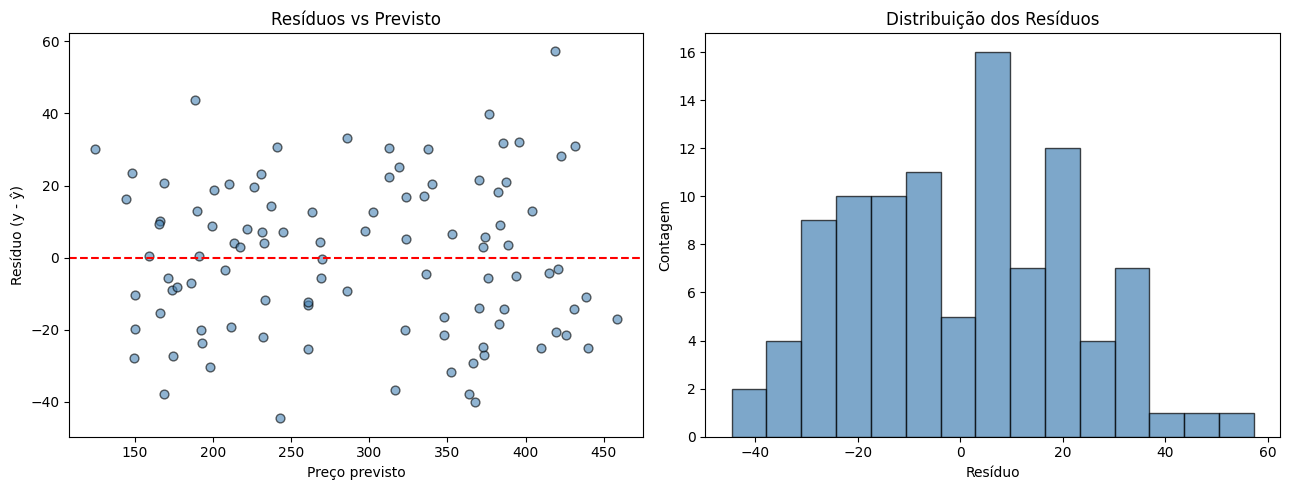

In [43]:
residuals = y_manual - y_pred_manual

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Resíduos vs previsto
axes[0].scatter(y_pred_manual, residuals, alpha=0.6,
                color='steelblue', edgecolors='black', s=40)
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_xlabel('Preço previsto')
axes[0].set_ylabel('Resíduo (y - ŷ)')
axes[0].set_title('Resíduos vs Previsto')

# Histograma dos resíduos
axes[1].hist(residuals, bins=15, color='steelblue', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Resíduo')
axes[1].set_ylabel('Contagem')
axes[1].set_title('Distribuição dos Resíduos')

plt.tight_layout()
plt.show()

Bons sinais:
- Resíduos centrados em torno de 0 (sem viés sistemático)
- Dispersão aproximadamente constante (homocedasticidade)
- Distribuição aproximadamente normal

Essas são as premissas sob as quais as propriedades estatísticas do OLS são válidas (p-values, intervalos de confiança, etc.).

### 8.3 Visualização univariada — reta ajustada para area_m2

Para visualizar a reta de regressão em 2D, vamos ajustar um modelo simples apenas com `area_m2`.

Modelo simples: preço = 47.49 + 2.65 * área


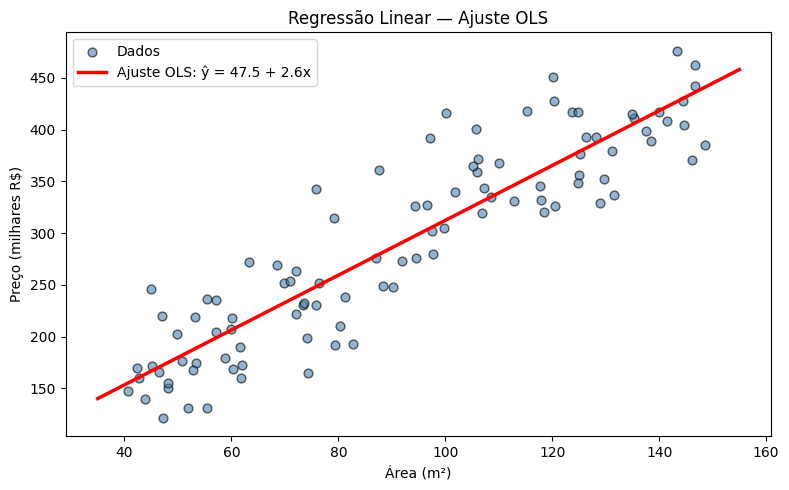

In [44]:
# OLS simples com uma feature
X_simple = np.column_stack([np.ones(n), houses['area_m2'].values])
theta_simple = np.linalg.inv(X_simple.T @ X_simple) @ X_simple.T @ y_manual

print(f"Modelo simples: preço = {theta_simple[0]:.2f} + {theta_simple[1]:.2f} * área")

# Gráfico
x_plot = np.linspace(35, 155, 100)
y_plot = theta_simple[0] + theta_simple[1] * x_plot

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(houses['area_m2'], houses['price_1000'], alpha=0.6,
           color='steelblue', edgecolors='black', s=40, label='Dados')
ax.plot(x_plot, y_plot, color='red', linewidth=2.5,
        label=f'Ajuste OLS: ŷ = {theta_simple[0]:.1f} + {theta_simple[1]:.1f}x')
ax.set_xlabel('Área (m²)')
ax.set_ylabel('Preço (milhares R$)')
ax.set_title('Regressão Linear — Ajuste OLS')
ax.legend()
plt.tight_layout()
plt.show()

---
## Resumo

| Abordagem | Vantagens | Desvantagens |
|-----------|-----------|---------------|
| **statsmodels** | Resumo estatístico completo (p-values, IC, R², teste F) | Precisa adicionar intercept manualmente; API menos conveniente para pipelines de ML |
| **scikit-learn** | API limpa, integra com cross-validation e pipelines | Sem p-values ou testes estatísticos |
| **OLS manual** | Entendimento completo do que acontece por baixo dos panos | Não é numericamente robusto para problemas grandes/mal-condicionados |

As três abordagens calculam a mesma coisa: o estimador OLS $\hat{\theta} = (\mathbf{X}^\top \mathbf{X})^{-1} \mathbf{X}^\top \mathbf{y}$.